**Project:** Data Mining II (2025/26)

**Group Number:** 12

**Members:**
- Beatriz Boura - 20250272
- Dinis Gaspar - 20221869
- Margarida Cruz - 20221929

**Project Overview**

In recent years, nonprofit organizations have faced a growing challenge: while charitable causes have multiplied, public tolerance for repeated, generic solicitations has significantly decreased, often leading to donor fatigue and long-term disengagement. To address this issue, the Civic Support Alliance (CSA)—a federation representing multiple humanitarian and social aid programs—seeks to modernize its fundraising strategy. Rather than launching blanket campaigns across their entire database, the organization aims to transition to a highly targeted approach. The goal is to maximize operational efficiency and maintain donor respect by contacting fewer, but more receptive, individuals. 

As data scientists, our team has been tasked with building a predictive machine learning system using historical demographic, interaction, and donation data accumulated from past campaigns. The primary objective is to accurately answer a fundamental question: Will this person donate if contacted? 

**Notebook Introduction**

In this notebook, we will develop Neural Networks, we will find parameter regions using our hold-out method splits as explained in the Modeling Tools notebook to test and we will then perform a parameter search to try and maximize performances.

**Benchmarks**

As the goal of this project is to help the CSA create and improve a targeted approach to donors with the goal of maximizing donations, we will use 2 baseline benchmarks as the minimum any model must achieve to be a good model:
+ Random prediction, which in a dataset with the imbalance present in the CSA's data yield an **F1-Score of ~0.34**
+ Predicting all 1, which is essentially, telling the CSA to keep sending out the camapaign to everyone. This is obviously not the desire of the CSA and as such the goal is to create models that can avoid this. Predicting all 1 in a dataset with this imbalance yields an **F1-Score of 0.4**

**Table of contents**<a id='toc0_'></a>    
1. [Imports](#toc1_)    
2. [Defining the Pipeline](#toc2_)    
3. [Base Model](#toc3_)    
4. [Model with Threshold optimization](#toc4_)    
5. [Maximum Depth](#toc5_)    
6. [Split Criterion](#toc6_)    
7. [Minimum Weight Fraction Leaf](#toc7_)    
8. [Minimum Samples to Split](#toc8_)    
9. [Parameter Search](#toc9_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=true
	minLevel=1
	maxLevel=3
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[Imports](#toc0_)

In this section we're importing everything we need, libraries and tools.

In [1]:
from sklearnex import patch_sklearn
patch_sklearn()
from utils_modeling import (OutlierClipper, CategoricalFeatureSelector, NumericalFeatureSelector, FeatureEngineer, DataCleaner, run_parameter_search)
import os
if os.getcwd() != 'c:\\Users\\dinis\\OneDrive\\Ambiente de Trabalho\\Faculdade - MGI-BI\\1º ano\\2º Semestre\\Data Mining II\\Project\\DM2_Project':
    %cd ..
import numpy as np
import pandas as pd
from sklearn.model_selection import TunedThresholdClassifierCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, MinMaxScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.neural_network import MLPClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import f1_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")
SEED=23
pd.options.display.max_columns = None

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project


In [2]:
train = pd.read_csv('Files/donors_train.csv')
with open('Files/Pickle Files/model_testing_skf.pkl', 'rb') as file:
    model_testing_skf = pickle.load(file)
with open('Files/Pickle Files/data_cleaner.pkl', 'rb') as file:
    data_cleaner = pickle.load(file)
with open('Files/Pickle Files/X_train_preprocessed.pkl', 'rb') as file:
    X_train_preprocessed = pickle.load(file)
with open('Files/Pickle Files/X_val_preprocessed.pkl', 'rb') as file:
    X_val_preprocessed = pickle.load(file)
with open('Files/Pickle Files/y_train.pkl', 'rb') as file:
    y_train = pickle.load(file)
with open('Files/Pickle Files/y_val.pkl', 'rb') as file:
    y_val = pickle.load(file)

In [3]:
X = train.drop('TARGET_B', axis=1)
y = train['TARGET_B']

# 2. <a id='toc2_'></a>[Defining the Pipeline](#toc0_)

We're first going to start by defining the pipeline we're gonna use as a base. This is the pipeline introduced in the Modeling Tools notebook, now with an MLPClassifier model.

In [4]:
# Categorical Feature Sub-Pipeline
# This is the part that handles the categorical columns, performing
# mode imputation, feature selection using our custom CategoricalFeatureSelector
# and finally one-hot encoding the features.
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('feature_selection',  CategoricalFeatureSelector()),
    # 3. Your specialized encoding (OneHot/Target) now receives imputed integers
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')),
])

# Numerical Feature Sub-Pipeline
# Here we take care of our numerical features, starting with outlier clipping and feature
# creation using our custom transformer, then scaling data, so that it can then 
# be imputed and numerical feature selection can be performed
num_pipe = Pipeline([
    ('clipper', OutlierClipper()),
    ('feature_engineer', FeatureEngineer()),
    ('scaler', RobustScaler()),
    ('imputer', KNNImputer()),
    ('feature_selection', NumericalFeatureSelector(random_state=SEED))
])

# Here we use a ColumnTransformer with column selectors to perform the split
# between numerical and categorical data, so that each subset can be directed
# to the appropriate sub-pipeline
preprocessor = ColumnTransformer([
    ('cat_section', cat_pipe, make_column_selector(dtype_exclude=[np.number])),
    ('num_section', num_pipe, make_column_selector(dtype_include=[np.number])),
],
verbose_feature_names_out=False)
#  

 
# Final Pipeline
nn_pipe = Pipeline([
    ('cleaner', data_cleaner),
    ('preprocessing', preprocessor),
    ('model', TunedThresholdClassifierCV(MLPClassifier(random_state=SEED),
                                         n_jobs=-1,
                                         scoring='f1',
                                         random_state=SEED,
                                         cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
                                         )) 
])

# We use the set_output to pandas so that intermediate transformers can use column
# names, since some of the default scikit-learn transformers by default return 
# Numpy arrays, which obviously don't have column names.
nn_pipe.set_output(transform="pandas")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaner', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,categorical_cols_values,"{'DONOR_GENDER': ['M', 'F', ...], 'INCOME_GROUP': array([1, 2, 3, 4, 5, 6, 7]), 'PEP_STAR': [0, 1], 'RECENCY_STATUS_96NK': ['S', 'A', ...], ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_section', ...), ('num_section', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that

Now let's start looking at models and results.

# Single Layer Networks

We're going to start by testing one layer networs with up to 50 neurons.

In [9]:
layer_size_list = np.arange(1, 50)
scores_train = []
scores_val = []
high_score=0
nof=0
for n_neurons in tqdm(layer_size_list):
    nn_single_layer_model = MLPClassifier((n_neurons), random_state=SEED)
    nn_single_layer_model.fit(X_train_preprocessed, y_train)
    train_pred = nn_single_layer_model.predict(X_train_preprocessed)
    val_pred = nn_single_layer_model.predict(X_val_preprocessed)
    scores_train.append(f1_score(y_train, train_pred))
    scores_val.append(f1_score(y_val, val_pred))
    if(f1_score(y_val, val_pred)>high_score):
        high_score = f1_score(y_val, val_pred)
        nof = layer_size_list[n_neurons-1]


print("Best maximum Depth: %d" %nof)
print("Mean F1 score in train with %d maximum depth: %f" % (nof, scores_train[nof-1]))
print("Mean F1 score in validation with %d maximum depth: %f" % (nof, high_score))

  0%|          | 0/49 [00:00<?, ?it/s]

Best maximum Depth: 43
Mean F1 score in train with 43 maximum depth: 0.427685
Mean F1 score in validation with 43 maximum depth: 0.244423


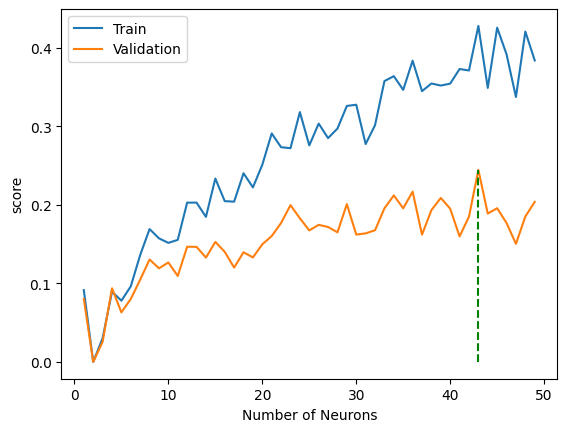

In [10]:
plt.plot(layer_size_list, scores_train, label='Train')
plt.plot(layer_size_list, scores_val, label = 'Validation')
plt.vlines(x=nof,ymax=high_score,ymin=min(scores_val),ls='--',colors='g')
plt.xlabel('Number of Neurons')
plt.ylabel('score')
plt.legend()

plt.show()

Overall the results are very poor, with peak at 43.

# Single Layer Networks with Threshold optimization

Now, we'll analyze the impact of the threshold optimizer on single-layer networks of up to 20 neurons.

In [11]:
layer_size_list = np.arange(1, 20)
scores_train = []
scores_val = []
high_score=0
nof=0
for n_neurons in tqdm(layer_size_list):
    nn_single_layer_model = TunedThresholdClassifierCV(MLPClassifier((n_neurons), random_state=SEED),
                                         n_jobs=-1,
                                         scoring='f1',
                                         random_state=SEED,
                                         cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
                                         )
    nn_single_layer_model.fit(X_train_preprocessed, y_train)
    train_pred = nn_single_layer_model.predict(X_train_preprocessed)
    val_pred = nn_single_layer_model.predict(X_val_preprocessed)
    scores_train.append(f1_score(y_train, train_pred))
    scores_val.append(f1_score(y_val, val_pred))
    if(f1_score(y_val, val_pred)>high_score):
        high_score = f1_score(y_val, val_pred)
        nof = layer_size_list[n_neurons-1]


print("Best number of neurone: %d" %nof)
print("Mean F1 score in train with %d maximum depth: %f" % (nof, scores_train[nof-1]))
print("Mean F1 score in validation with %d maximum depth: %f" % (nof, high_score))

  0%|          | 0/19 [00:00<?, ?it/s]

Best number of neurone: 4
Mean F1 score in train with 4 maximum depth: 0.427981
Mean F1 score in validation with 4 maximum depth: 0.416064


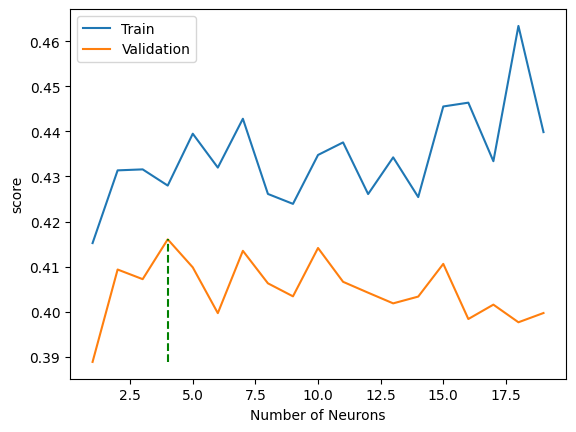

In [12]:
plt.plot(layer_size_list, scores_train, label='Train')
plt.plot(layer_size_list, scores_val, label = 'Validation')
plt.vlines(x=nof,ymax=high_score,ymin=min(scores_val),ls='--',colors='g')
plt.xlabel('Number of Neurons')
plt.ylabel('score')
plt.legend()

plt.show()

Adding the optimizer drastically improves results and now we have a peak at 4 neurons, indicating that this problem likely achieves best scores with simple networks.

# Activation Functions

An activation function in an MLPClassifier introduces non-linearity to the network, allowing it to learn complex, non-linear patterns rather than just straight lines. There are 4 options: 'identity', 'logistic', 'tanh' and 'relu'.

In [13]:
activation_f_list = ['identity', 'logistic', 'tanh', 'relu']
scores_train = []
scores_val = []
high_score=0
nof=0
for i in tqdm(range(len(activation_f_list))):
    nn_single_layer_model = TunedThresholdClassifierCV(MLPClassifier((4), activation=activation_f_list[i], random_state=SEED),
                                         n_jobs=-1,
                                         scoring='f1',
                                         random_state=SEED,
                                         cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    )
    nn_single_layer_model.fit(X_train_preprocessed, y_train)
    train_pred = nn_single_layer_model.predict(X_train_preprocessed)
    val_pred = nn_single_layer_model.predict(X_val_preprocessed)
    print("Activation function: {}".format(activation_f_list[i]))
    print("Mean F1 score in train: {}".format(f1_score(y_train, train_pred)))
    print("Mean F1 score in validation: {}\n".format(f1_score(y_val, val_pred)))

  0%|          | 0/4 [00:00<?, ?it/s]

Activation function: identity
Mean F1 score in train: 0.42209885386819485
Mean F1 score in validation: 0.4065271372827244

Activation function: logistic
Mean F1 score in train: 0.4236760124610592
Mean F1 score in validation: 0.4058641975308642

Activation function: tanh
Mean F1 score in train: 0.429965094424058
Mean F1 score in validation: 0.40954415954415957

Activation function: relu
Mean F1 score in train: 0.4279812723767557
Mean F1 score in validation: 0.41606367583212733



The relu activation function (default) achieved the best score and, since it's also the fastest and most popular option, we won't include the other in the parameter search.

# Parameter Search

We're going to test several combinations across our grid to optimize our preprocessing and modeling steps efficiently. This is because neural networks are highly sensitive to data scaling, meaning standard interval scalers will be tested alongside the distance-based imputer, while the solver and regularization combinations will be isolated to find the most stable optimization path:

+ In preprocessing:
    + Scaler: We are going to test three scaling methodologies: PowerTransformer, MinMaxScaler, and RobustScaler (which scales via quartile values to mitigate outlier weight distortion). The PowerTransformer applies variance-stabilizing transformations to bring feature distributions close to a Gaussian Normal distribution before standardizing them to a mean of 0 and variance of 1, just like StandardScaler would.
    + Imputer: We will only use the distance-based KNNImputer configured with 50 neighbors to allow us to test more model parameter combinations.
    + Clipping: Three outlier-handling approaches are tested across the combinations: no clipping at all (None), and clipping based on the IQR method for both normal and extreme outliers following normal convention of 1.5 and 3 times IQR beyond the quartiles, respectively.

+ In the model (configured with relu activation, early stopping, and a max of 300 iterations):
    + Solvers: We are thoroughly expanding our weight optimization strategies by testing three different solvers: adam (an adaptive gradient-descent optimizer), lbfgs (a quasi-Newton optimizer that handles smaller datasets and micro-architectures with highly stable curvature estimation), and sgd (stochastic gradient descent). 
    + Hidden Layer Sizes: Guided by preliminary validation curves showing an early peak followed by severe overfitting, we are focusing primarily on single-layer micro-architectures with widths of (3,), (4,), and (5,) neurons, while also introducing a small multi-layer option of (4, 2) to test basic deep representation capabilities.
    + Alpha Regularization: To control weight inflation and eliminate the high-variance fluctuations observed in the initial validation runs, we are searching across heavily regularized L2 penalty values spanning from 0.01 up to an aggressive penalty of 5.0 (specifically testing 0.01, 0.1, 1.0, and 5.0).

In [5]:
param_grid = {
    'preprocessing__num_section__scaler' : [PowerTransformer(), MinMaxScaler(), RobustScaler()], 
    'preprocessing__num_section__imputer' : [KNNImputer(n_neighbors=50)], 
    'preprocessing__num_section__clipper' : [None, OutlierClipper(method='iqr', iqr_multiplier=1.5), OutlierClipper(method='iqr', iqr_multiplier=3)],
    'model__estimator' : [MLPClassifier(activation='relu', early_stopping=True, max_iter=300, random_state=SEED)],
    'model__estimator__solver' : ['adam', 'lbfgs', 'sgd'],
    'model__estimator__hidden_layer_sizes' : [(3,), (4,), (5,), (4, 2)],
    'model__estimator__alpha' : [0.01, 0.1, 1.0, 5.0]
}

```python
run_parameter_search(grid=param_grid,
                     cv=model_testing_skf, 
                     X=X, y=y,
                     model=nn_pipe,
                     metrics=['f1', 'precision', 'recall'],
                     results_file_dir='Files/Pickle Files/Results/NN_GridSearch_Results.pkl',
                     model_file_dir='Files/Pickle Files/Models/NN_GridSearch_Best_Model.pkl',
                     refit=True,
                     n_jobs=-1)

In [8]:
result_df = pd.read_pickle('Files/Pickle Files/Results/NN_GridSearch_Results.pkl')
result_df.head()

,params_config,model__estimator,model__estimator__alpha,model__estimator__hidden_layer_sizes,model__estimator__solver,preprocessing__num_section__clipper,preprocessing__num_section__imputer,preprocessing__num_section__scaler,mean_fit_time,mean_val_f1,std_val_f1,mean_train_f1,std_train_f1,mean_val_precision,std_val_precision,mean_train_precision,std_train_precision,mean_val_recall,std_val_recall,mean_train_recall,std_train_recall,status
341,"{'model__estimator': MLPClassifier(alpha=5.0, ...","MLPClassifier(alpha=5.0, early_stopping=True, ...",5.0,"(3,)",lbfgs,OutlierClipper(iqr_multiplier=3),KNNImputer(n_neighbors=50),RobustScaler(),71.925975,0.418195,0.004496,0.428504,0.002621,0.282655,0.007868,0.289435,0.007404,0.807080,0.042043,0.828687,0.045258,Success
334,"{'model__estimator': MLPClassifier(alpha=5.0, ...","MLPClassifier(alpha=5.0, early_stopping=True, ...",5.0,"(3,)",lbfgs,None,KNNImputer(n_neighbors=50),MinMaxScaler(),79.171145,0.417740,0.004495,0.420762,0.003690,0.279897,0.008083,0.281741,0.006468,0.827729,0.049968,0.834882,0.050580,Success
337,"{'model__estimator': MLPClassifier(alpha=5.0, ...","MLPClassifier(alpha=5.0, early_stopping=True, ...",5.0,"(3,)",lbfgs,OutlierClipper(),KNNImputer(n_neighbors=50),MinMaxScaler(),81.600365,0.417654,0.006348,0.425968,0.005632,0.286409,0.009259,0.291984,0.003586,0.774631,0.041292,0.791740,0.060063,Success
232,"{'model__estimator': MLPClassifier(alpha=5.0, ...","MLPClassifier(alpha=5.0, early_stopping=True, ...",1.0,"(3,)",lbfgs,OutlierClipper(iqr_multiplier=3),KNNImputer(n_neighbors=50),MinMaxScaler(),78.879286,0.417652,0.003806,0.422774,0.001436,0.288088,0.007984,0.291924,0.006063,0.761652,0.031793,0.769395,0.041883,Success
391,"{'model__estimator': MLPClassifier(alpha=5.0, ...","MLPClassifier(alpha=5.0, early_stopping=True, ...",5.0,"(5,)",lbfgs,OutlierClipper(),KNNImputer(n_neighbors=50),MinMaxScaler(),83.836867,0.417298,0.004842,0.432586,0.002929,0.285796,0.002386,0.297119,0.004702,0.774926,0.041776,0.797050,0.035093,Success


In [9]:
result_df.iloc[0]['params_config']

{'model__estimator': MLPClassifier(alpha=5.0, early_stopping=True, hidden_layer_sizes=(4, 2),
               max_iter=300, random_state=23, solver='sgd'),
 'model__estimator__alpha': 5.0,
 'model__estimator__hidden_layer_sizes': (3,),
 'model__estimator__solver': 'lbfgs',
 'preprocessing__num_section__clipper': OutlierClipper(iqr_multiplier=3),
 'preprocessing__num_section__imputer': KNNImputer(n_neighbors=50),
 'preprocessing__num_section__scaler': RobustScaler()}

In [11]:
with open('Files/Pickle Files/Models/NN_GridSearch_Best_Model.pkl', 'rb') as file:
    nn_bestmodel = pickle.load(file)

In [12]:
nn_bestmodel['model'].best_threshold_

np.float64(0.19024133683697886)

The best parameter combination achieved a mean validation F1-score of 0.418195 and a mean training F1-score of 0.428504 indicating no severe over or under fitting. It used RobustScaler and Outlier clipping based on the IQR method for extreme outliers (multiplier 3) and the KNNImputer. The model used a single 3 Neuron Network, with the lbfgs solver and alpha of 5.

Additionally, it has an optimized decision threshold of ~0.19 which means it allows for significantly more predicted positives, in other words predicts many more donations than if it were using the default threshold. This means that the recall is higher using this threshold which means that the model is finding a higher rate of the true donors. This comes with the side effect of also sending the campaign to more people who won't donate (False Postives) lowering precision. But as the goal is to maximize donations while optimizing the campaign distribution process, this seems like a decent compromise.

# Test Set Prediction

The last thing to do is to predict for the test set. For that we'll read the test set and the pickle file of the best model and then generate the prediction and export it to a CSV file as instructed.

In [13]:
test = pd.read_csv('Files/donors_test.csv')


In [15]:
pred_test = pd.DataFrame(nn_bestmodel.predict(test), index=test['CONTROL_NUMBER'], columns=['TARGET_B'])
pred_test

,TARGET_B
CONTROL_NUMBER,
122653,0
184239,1
5172,1
135377,1
62119,1
...,...
54438,0
122194,1
106603,1


In [16]:
pred_test.to_csv('Files/Submissions/DM2DT_Group12_Version21.csv')

The best model from the Neural Network parameter search achieves an F1-Score of 0.43184 as the public score on Kaggle.